# **Câncer de Tireóide**

## **1. Introdução**

O câncer de tireoide é uma das neoplasias mais comuns, e sua detecção precoce é essencial para um tratamento eficaz e melhores resultados prognósticos. Com o crescimento das ferramentas de análise de dados e machine learning, surgem novas oportunidades para aprimorar os métodos de diagnóstico e prever a evolução da doença. Este projeto tem como objetivo utilizar o PyCaret, uma biblioteca de machine learning em Python, para analisar o conjunto de dados específico para câncer de tireoide. Através da exploração de diferentes algoritmos e técnicas de modelagem, buscamos identificar o modelo mais eficiente para prever diagnósticos, contribuindo assim para avanços na detecção e manejo dessa condição.

In [ ]:
# Instalando biblioteca

# !pip install pycaret

In [ ]:
# Carregando bibliotecas

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from pycaret.classification import *
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [ ]:
sns.set();

In [ ]:
# Carregando base de dados

dados = pd.read_csv('/content/drive/MyDrive/Portfólio/Dados/Thyroid_Diff.csv')

In [ ]:
# Visualizando base de dados

dados.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


**Fonte:** https://www.kaggle.com/datasets/jainaru/thyroid-disease-data/data

**Features**

* **Age:** The age of the patient at the time of diagnosis or treatment.

* **Gender:** The gender of the patient (male or female).

* **Smoking:** Whether the patient is a smoker or not.

* **Hx Smoking:** Smoking history of the patient (e.g., whether they have ever smoked).

* **Hx Radiotherapy:** History of radiotherapy treatment for any condition.

* **Thyroid Function:** The status of thyroid function, possibly indicating if there are any abnormalities.

* **Physical Examination:** Findings from a physical examination of the patient, which may include palpation of the thyroid gland and surrounding structures.

* **Adenopathy:** Presence or absence of enlarged lymph nodes (adenopathy) in the neck region.

* **Pathology:** Specific types of thyroid cancer as determined by pathology examination of biopsy samples.

* **Focality:** Whether the cancer is unifocal (limited to one location) or multifocal (present in multiple locations).

* **Risk:** The risk category of the cancer based on various factors, such as tumor size, extent of spread, and histological type.

* **T:** Tumor classification based on its size and extent of invasion into nearby structures.

* **N:** Nodal classification indicating the involvement of lymph nodes.

* **M:** Metastasis classification indicating the presence or absence of distant metastases.

* **Stage:** The overall stage of the cancer, typically determined by combining T, N, and M classifications.

* **Response:** Response to treatment, indicating whether the cancer responded positively, negatively, or remained stable after treatment.

* **Recurred:** Indicates whether the cancer has recurred after initial treatment.

## **2. Análise Exploratória de Dados**

In [ ]:
# Informações sobre o dataset

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

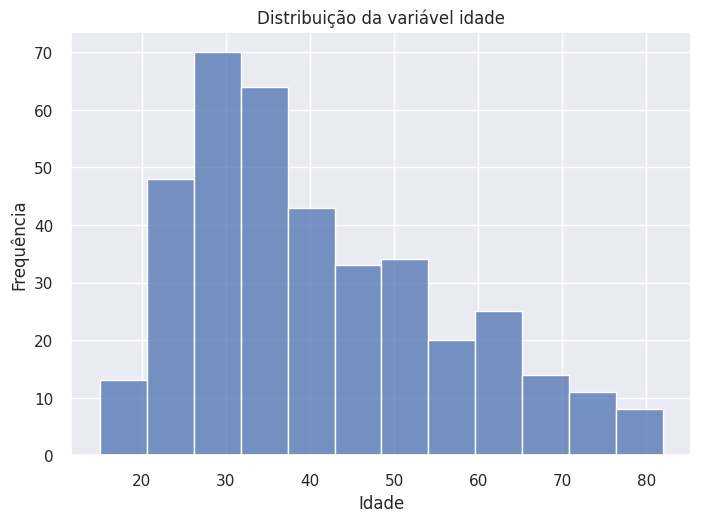

In [ ]:
# Gráfico 1: distribuição da variável idade

sns.histplot(dados['Age'])

plt.title('Distribuição da variável idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')

plt.show();

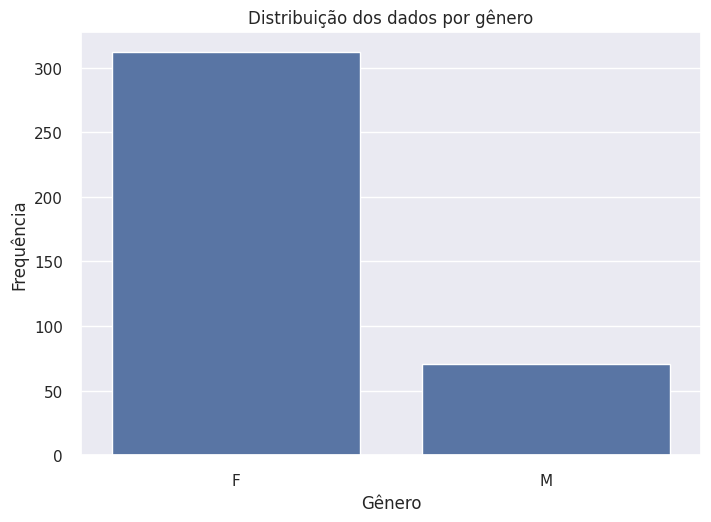

In [ ]:
# Gráfico 2: distribuição dos dados por gênero

sns.countplot(x = 'Gender', data = dados)

plt.title('Distribuição dos dados por gênero')
plt.xlabel('Gênero')
plt.ylabel('Frequência')

plt.show();

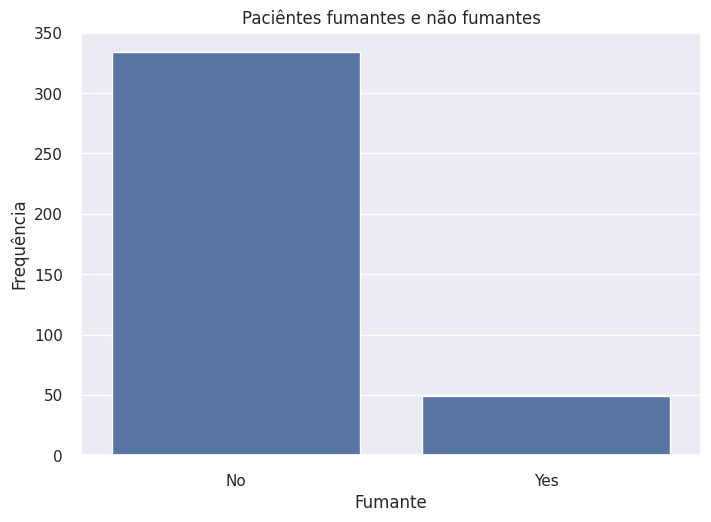

In [ ]:
# Gráfico 3: Paciêntes fumantes e não fumantes

sns.countplot(x = 'Smoking', data = dados)

plt.title('Paciêntes fumantes e não fumantes')
plt.xlabel('Fumante')
plt.ylabel('Frequência')

plt.show();

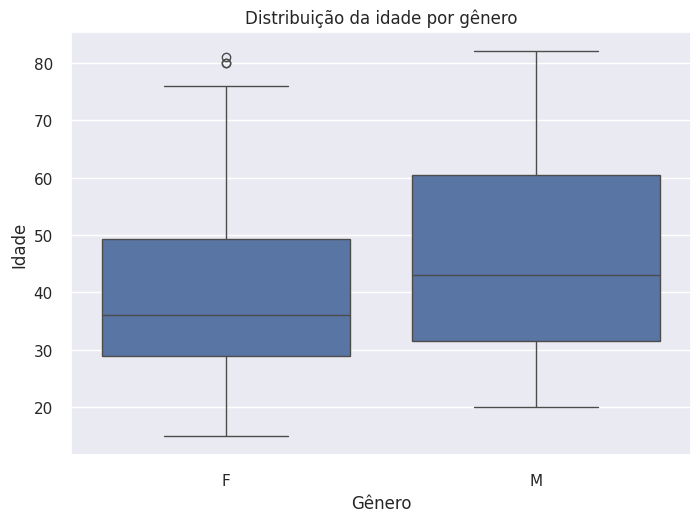

In [ ]:
# Gráfico 4: distribuição da idade por gênero

sns.boxplot(x = 'Gender', y = 'Age', data = dados)

plt.title('Distribuição da idade por gênero')
plt.xlabel('Gênero')
plt.ylabel('Idade')

plt.show();

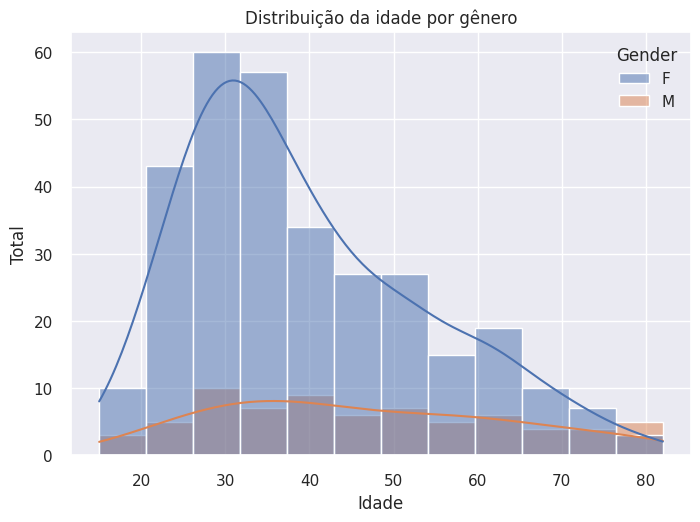

In [ ]:
# Gráfico 5: distribuição da idade por gênero

sns.histplot(data = dados,
             x = "Age",
             hue = "Gender",
             kde = True)

plt.title('Distribuição da idade por gênero')
plt.xlabel('Idade')
plt.ylabel('Total')

plt.show();

## **3. Pré-Processamento de Dados**

In [ ]:
# Separando os dados em previsores e classe

previsores = dados.drop('Recurred', axis=1)
classe = dados['Recurred']

In [ ]:
# Escalonando os dados

## Instânciando objeto
scaler = MinMaxScaler()
label = LabelEncoder()

## Aplicando aos dados
previsores[['Age']] = scaler.fit_transform(previsores[['Age']])
previsores['Gender'] = label.fit_transform(previsores[['Gender']])
previsores['Smoking'] = label.fit_transform(previsores[['Smoking']])
previsores['Hx Smoking'] = label.fit_transform(previsores[['Hx Smoking']])
previsores['Hx Radiothreapy'] = label.fit_transform(previsores[['Hx Radiothreapy']])
previsores['Thyroid Function'] = label.fit_transform(previsores[['Thyroid Function']])
previsores['Physical Examination'] = label.fit_transform(previsores[['Physical Examination']])
previsores['Adenopathy'] = label.fit_transform(previsores[['Adenopathy']])
previsores['Pathology'] = label.fit_transform(previsores[['Pathology']])
previsores['Focality'] = label.fit_transform(previsores[['Focality']])
previsores['Risk'] = label.fit_transform(previsores[['Risk']])
previsores['T'] = label.fit_transform(previsores[['T']])
previsores['N'] = label.fit_transform(previsores[['N']])
previsores['M'] = label.fit_transform(previsores[['M']])
previsores['Stage'] = label.fit_transform(previsores[['Stage']])
previsores['Response'] = label.fit_transform(previsores[['Response']])

In [ ]:
# Dividindo os dados em treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(previsores,
                                                        classe,
                                                        test_size = 0.3,
                                                        random_state = 0)

In [ ]:
# Verificando distribuição dos dados

print(X_treino.shape)
print(X_teste.shape)
print(y_treino.shape)
print(y_teste.shape)

(268, 16)
(115, 16)
(268,)
(115,)


## **4. Construindo Modelo**

In [ ]:
# Verificando a melhor técnica a se usar com o PyCaret

clf = setup(data = dados,
            target = 'Recurred',
            session_id = 0)
compare_models()

,Description,Value
0,Session id,0
1,Target,Recurred
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(383, 17)"
5,Transformed data shape,"(383, 49)"
6,Transformed train set shape,"(268, 49)"
7,Transformed test set shape,"(115, 49)"
8,Numeric features,1
9,Categorical features,15


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9591,0.9810,0.9591,0.9594,0.9584,0.8959,0.8978,0.4370
lr,Logistic Regression,0.9553,0.9830,0.9553,0.9581,0.9546,0.8870,0.8917,2.1990
xgboost,Extreme Gradient Boosting,0.9553,0.9871,0.9553,0.9582,0.9550,0.8880,0.8919,0.5690
gbc,Gradient Boosting Classifier,0.9517,0.9817,0.9517,0.9544,0.9513,0.8791,0.8832,0.6390
lda,Linear Discriminant Analysis,0.9517,0.9792,0.9517,0.9543,0.9504,0.8761,0.8818,0.2870
lightgbm,Light Gradient Boosting Machine,0.9514,0.9926,0.9514,0.9535,0.9511,0.8782,0.8814,0.4760
ridge,Ridge Classifier,0.9480,0.9811,0.9480,0.9516,0.9458,0.8644,0.8726,0.5030
rf,Random Forest Classifier,0.9479,0.9842,0.9479,0.9489,0.9470,0.8678,0.8710,0.5240
nb,Naive Bayes,0.9405,0.9781,0.9405,0.9447,0.9397,0.8515,0.8578,0.2800
ada,Ada Boost Classifier,0.9368,0.9892,0.9368,0.9445,0.9370,0.8481,0.8561,0.4860


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=0, verbose=0,
                     warm_start=False)

In [ ]:
# Carregando biblioteca

from sklearn.ensemble import ExtraTreesClassifier

In [ ]:
# Instânciando modelo com os parâmetros estimados pelo PyCaret

modelo = ExtraTreesClassifier(bootstrap=False,
                              ccp_alpha=0.0,
                              class_weight=None,
                              criterion='gini',
                              max_depth=None,
                              max_features='sqrt',
                              max_leaf_nodes=None,
                              max_samples=None,
                              min_impurity_decrease=0.0,
                              min_samples_leaf=1,
                              min_samples_split=2,
                              min_weight_fraction_leaf=0.0,
                              monotonic_cst=None,
                              n_estimators=100,
                              n_jobs=-1,
                              oob_score=False,
                              random_state=0,
                              verbose=0,
                              warm_start=False)

In [ ]:
# Treinando o modelo

modelo.fit(X_treino, y_treino)

ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=0, verbose=0,
                     warm_start=False)

In [ ]:
# Realizando previsões com os dados de teste

previsoes = modelo.predict(X_teste)

## **5. Avaliando Modelo**

In [ ]:
# Avaliando Desempenho do Modelo com Classification Report

print(classification_report(y_teste, previsoes))

              precision    recall  f1-score   support

          No       0.93      0.99      0.96        79
         Yes       0.97      0.83      0.90        36

    accuracy                           0.94       115
   macro avg       0.95      0.91      0.93       115
weighted avg       0.94      0.94      0.94       115



## **6. Considerações Finais**

Os resultados obtidos na análise do modelo para detecção de câncer de tireoide demonstram um desempenho robusto, com uma acurácia geral de 94%. A precisão e o recall para a classe "No" foram especialmente altos, indicando que o modelo é eficaz em identificar corretamente a ausência da doença. Embora a precisão para a classe "Yes" seja elevada, o recall de 83% sugere que há espaço para melhorias na detecção de casos positivos. O f1-score médio de 0.93 reflete um bom equilíbrio entre precisão e recall, mas reforça a necessidade de otimizações para minimizar falsos negativos. Esses resultados evidenciam o potencial do machine learning como uma ferramenta valiosa no diagnóstico precoce do câncer de tireoide, podendo contribuir significativamente para melhores desfechos clínicos. Futuros trabalhos podem focar na melhoria da sensibilidade do modelo e na validação com conjuntos de dados adicionais.